# Классификация

## Задание №1

Найти данные для классификации. Данные в группе повторяться не
должны. Предобработать данные, если это необходимо.

In [1]:
import kagglehub
import pandas as pd
import os


path = kagglehub.dataset_download("ekibee/car-sales-information")

file_path = os.path.join(path, "all_regions.csv")
df = pd.read_csv(file_path)

#### Первые N строк

In [2]:
n = 5
df.head(n)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


#### Общая информация о датасете

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

#### Дубликаты

In [4]:
df.duplicated().sum()

np.int64(0)

#### Пустые значения

In [5]:
df.isna().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

#### Удаление строк с пустыми значениями

In [6]:
df.dropna(how="any", inplace=True, ignore_index=True)
df.isna().sum()

brand                   0
name                    0
bodyType                0
color                   0
fuelType                0
year                    0
mileage                 0
transmission            0
power                   0
price                   0
vehicleConfiguration    0
engineName              0
engineDisplacement      0
date                    0
location                0
link                    0
description             0
parse_date              0
dtype: int64

#### Число строк и столбцов

In [7]:
df.shape

(399192, 18)

#### Удаление ненужных столбцов, работа над типами данных

In [8]:
df = df.drop(columns=["link", "parse_date", "description", "date", "location", "engineName", "vehicleConfiguration", "name", "color"])
df.head()

,brand,bodyType,fuelType,year,mileage,transmission,power,price,engineDisplacement
0,Лада,Хэтчбек 3 дв.,Бензин,1996.0,37000.0,Механика,33.0,95000,0.7 LTR
1,Toyota,Хэтчбек 5 дв.,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 LTR
2,Лада,Лифтбек,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 LTR
3,Chevrolet,Джип 5 дв.,Бензин,2002.0,220000.0,Механика,80.0,450000,1.7 LTR
4,Лада,Хэтчбек 5 дв.,Бензин,2007.0,185000.0,Механика,81.0,120000,1.6 LTR


#### Приведение типов данных

In [9]:
df["year"] = df["year"].astype("int64")
df["mileage"] = df["mileage"].astype("int64")
df["power"] = df["power"].astype("int64")
df["engineDisplacement"] = df["engineDisplacement"].str.rstrip("LTR").astype("float64")
df.head()

,brand,bodyType,fuelType,year,mileage,transmission,power,price,engineDisplacement
0,Лада,Хэтчбек 3 дв.,Бензин,1996,37000,Механика,33,95000,0.7
1,Toyota,Хэтчбек 5 дв.,Бензин,2002,295000,АКПП,87,380000,1.3
2,Лада,Лифтбек,Бензин,2018,16000,Механика,106,795000,1.6
3,Chevrolet,Джип 5 дв.,Бензин,2002,220000,Механика,80,450000,1.7
4,Лада,Хэтчбек 5 дв.,Бензин,2007,185000,Механика,81,120000,1.6


#### One-hot encoding

In [10]:
df = pd.get_dummies(df, columns=["transmission", "fuelType", "bodyType"])
df

,brand,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,...,bodyType_Джип 5 дв.,bodyType_Купе,bodyType_Лифтбек,bodyType_Минивэн,bodyType_Открытый,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.
0,Лада,1996,37000,33,95000,0.7,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,Toyota,2002,295000,87,380000,1.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,Лада,2018,16000,106,795000,1.6,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,Chevrolet,2002,220000,80,450000,1.7,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,Лада,2007,185000,81,120000,1.6,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,Chevrolet,2008,280000,109,550000,1.6,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
399188,Лада,1985,300000,64,165000,1.3,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
399189,Toyota,2020,32000,202,3100000,2.5,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
399190,Лада,1995,354000,79,298000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
luxury_brands = ['BMW', 'Audi', 'Mercedes-Benz', 'Lexus', 'Porsche', 'Land Rover', 
                 'Infiniti', 'Volvo', 'Jaguar', 'Cadillac', 'Lincoln', 'Acura', 
                 'Bentley', 'Genesis', 'McLaren', 'Ferrari', 'Rolls-Royce', 'Maserati', 
                 'Aston Martin', 'Maybach']

premium_brands = ['Volkswagen', 'Toyota', 'Honda', 'Nissan', 'Mazda', 'Subaru', 
                  'Hyundai', 'Kia', 'Ford', 'Opel', 'Peugeot', 'Citroen', 'Skoda', 
                  'Renault', 'Chevrolet', 'Mitsubishi', 'Suzuki', 'Mini', 'Saab']

budget_brands = ['Лада', 'ГАЗ', 'УАЗ', 'ИЖ', 'ЗАЗ', 'ЛуАЗ', 'ТагАЗ', 'Богдан', 'Москвич',
                 'Dacia', 'Lada', 'ВАЗ']

chinese_brands = ['Chery', 'Haval', 'Great Wall', 'Geely', 'BYD', 'Changan', 'JAC', 
                  'EXEED', 'Li', 'GAC', 'Zotye', 'Dongfeng', 'FAW', 'Haima', 'Brilliance']

other_brands = [brand for brand in df['brand'].unique() 
                if brand not in luxury_brands + premium_brands + budget_brands + chinese_brands]


def map_brand_segment(brand):
    if brand in luxury_brands:
        return 'luxury'
    elif brand in premium_brands:
        return 'premium'
    elif brand in budget_brands:
        return 'budget'
    elif brand in chinese_brands:
        return 'chinese'
    else:
        return 'other'

df['brand_segment'] = df['brand'].apply(map_brand_segment)
df

,brand,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,...,bodyType_Купе,bodyType_Лифтбек,bodyType_Минивэн,bodyType_Открытый,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_segment
0,Лада,1996,37000,33,95000,0.7,False,False,True,False,...,False,False,False,False,False,False,False,True,False,budget
1,Toyota,2002,295000,87,380000,1.3,True,False,False,False,...,False,False,False,False,False,False,False,False,True,premium
2,Лада,2018,16000,106,795000,1.6,False,False,True,False,...,False,True,False,False,False,False,False,False,False,budget
3,Chevrolet,2002,220000,80,450000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,premium
4,Лада,2007,185000,81,120000,1.6,False,False,True,False,...,False,False,False,False,False,False,False,False,True,budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,Chevrolet,2008,280000,109,550000,1.6,True,False,False,False,...,False,False,False,False,False,True,False,False,False,premium
399188,Лада,1985,300000,64,165000,1.3,False,False,True,False,...,False,False,False,False,False,True,False,False,False,budget
399189,Toyota,2020,32000,202,3100000,2.5,True,False,False,False,...,False,False,False,False,False,True,False,False,False,premium
399190,Лада,1995,354000,79,298000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,budget


#### One-hot encoding

In [12]:
df = pd.get_dummies(df, columns=['brand_segment'], prefix='brand')
df = df.drop(columns = ["brand"])
df

,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,...,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium
0,1996,37000,33,95000,0.7,False,False,True,False,True,...,False,False,False,True,False,True,False,False,False,False
1,2002,295000,87,380000,1.3,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,2018,16000,106,795000,1.6,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
3,2002,220000,80,450000,1.7,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
4,2007,185000,81,120000,1.6,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,2008,280000,109,550000,1.6,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
399188,1985,300000,64,165000,1.3,False,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False
399189,2020,32000,202,3100000,2.5,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
399190,1995,354000,79,298000,1.7,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False


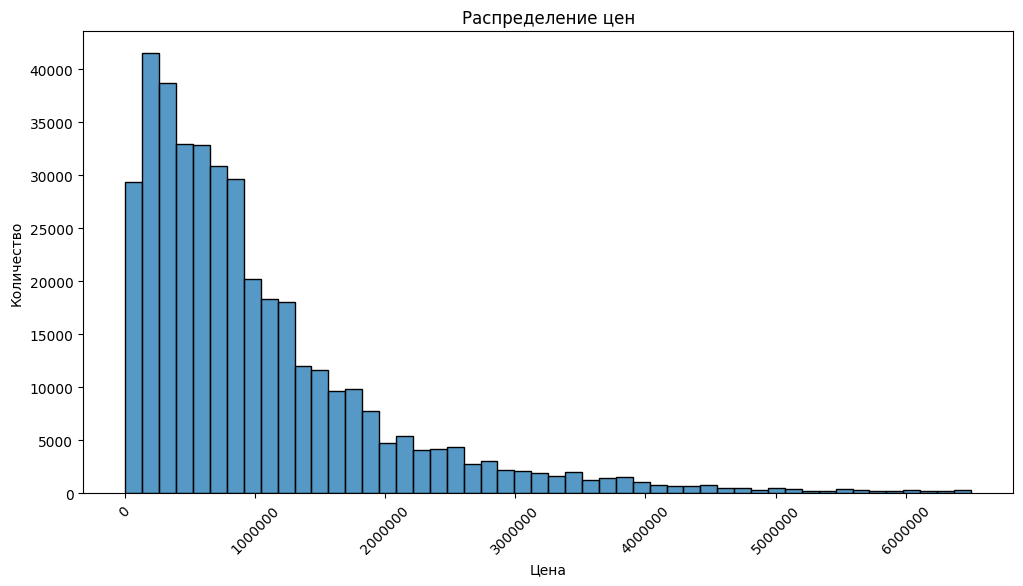

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['price'] <= df['price'].quantile(0.99)], x='price', bins=50)

plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.xlabel('Цена')
plt.ylabel('Количество')
plt.title('Распределение цен')
plt.show()

#### Разделение автомобилей на категории

In [14]:
def price_segment(price):
    if price <= 500000:
        return 'дешевый'
    elif price <= 1120000:
        return 'средний'
    else:
        return 'дорогой'

df['price_segment'] = df['price'].apply(price_segment)
df

,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,...,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium,price_segment
0,1996,37000,33,95000,0.7,False,False,True,False,True,...,False,False,True,False,True,False,False,False,False,дешевый
1,2002,295000,87,380000,1.3,True,False,False,False,True,...,False,False,False,True,False,False,False,False,True,дешевый
2,2018,16000,106,795000,1.6,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,средний
3,2002,220000,80,450000,1.7,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,дешевый
4,2007,185000,81,120000,1.6,False,False,True,False,True,...,False,False,False,True,True,False,False,False,False,дешевый
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,2008,280000,109,550000,1.6,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,средний
399188,1985,300000,64,165000,1.3,False,False,True,False,True,...,True,False,False,False,True,False,False,False,False,дешевый
399189,2020,32000,202,3100000,2.5,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,дорогой
399190,1995,354000,79,298000,1.7,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,дешевый


In [15]:
X = df.drop(['price_segment', 'price'], axis=1)
y = df['price_segment']
X

,year,mileage,power,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,fuelType_Дизель,...,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium
0,1996,37000,33,0.7,False,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,2002,295000,87,1.3,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2018,16000,106,1.6,False,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,2002,220000,80,1.7,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,2007,185000,81,1.6,False,False,True,False,True,False,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,2008,280000,109,1.6,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
399188,1985,300000,64,1.3,False,False,True,False,True,False,...,False,True,False,False,False,True,False,False,False,False
399189,2020,32000,202,2.5,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
399190,1995,354000,79,1.7,False,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [16]:
y

0         дешевый
1         дешевый
2         средний
3         дешевый
4         дешевый
           ...   
399187    средний
399188    дешевый
399189    дорогой
399190    дешевый
399191    дешевый
Name: price_segment, Length: 399192, dtype: object

## Задание №2

Изобразить гистограмму, которая показывает баланс классов. Сделать
выводы.

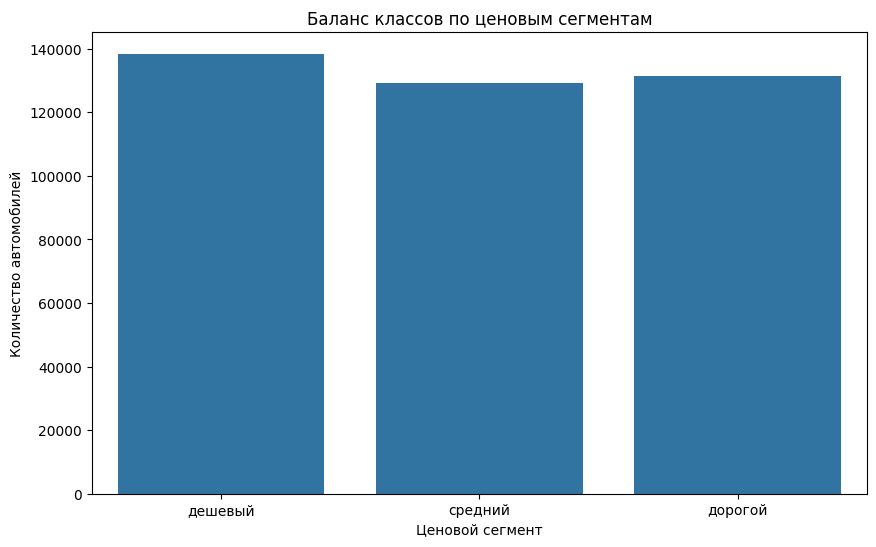

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='price_segment', order=['дешевый', 'средний', 'дорогой'])
plt.title('Баланс классов по ценовым сегментам')
plt.xlabel('Ценовой сегмент')
plt.ylabel('Количество автомобилей')
plt.show()

## Задание №3

Разбить выборку на тренировочную и тестовую. Тренировочная для
обучения модели, тестовая для проверки ее качества.

In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Задание №4

Применить алгоритмы классификации: логистическая регрессия, SVM,
KNN. Построить матрицу ошибок по результатам работы моделей
(использовать confusion_matrix из sklearn.metrics).

### Логистическая регрессия

#### Предобработка данных

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

#### Обучение модели

In [20]:
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

#### Матрциа ошибок

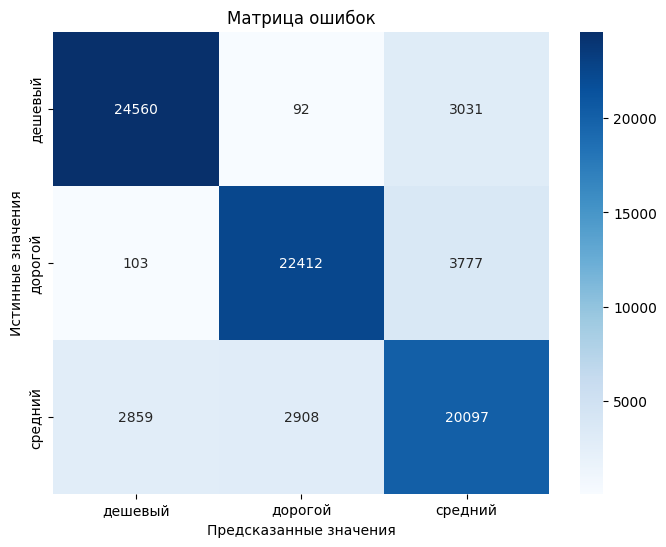

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Матрица ошибок')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

### Метод опорных векторов

In [22]:
from sklearn.svm import SVC, LinearSVC


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ])

model_svc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
        dual=False
    ))
])

model_svc.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'mileage', 'power',
                                                   'engineDisplacement']),
                                                 ('cat', 'passthrough',
                                                  ['transmission_АКПП',
                                                   'transmission_Вариатор',
                                                   'transmission_Механика',
                                                   'transmission_Робот',
                                                   'fuelType_Бензин',
                                                   'fuelType_Дизель',
                                                   'fuelType_Электро',
                                                   'bodyType_Джип 3 дв.',
                                                   'bodyType_Джип 5 дв.',
                                                   'bodyType_Купе',
                                                   'bodyType_Лифтбек',
                                                   'bodyType_Минивэн',
                                                   'bodyType_Открытый',
                                                   'bodyType_Пикап',
                                                   'bodyType_Седан',
                                                   'bodyType_Универсал',
                                                   'bodyType_Хэтчбек 3 дв.',
                                                   'bodyType_Хэтчбек 5 дв.',
                                                   'brand_budget',
                                                   'brand_chinese',
                                                   'brand_luxury',
                                                   'brand_other',
                                                   'brand_premium'])])),
                ('classifier',
                 LinearSVC(class_weight='balanced', dual=False,
                           random_state=42))])

In [23]:
y_predict_svm = model_svc.predict(X_test)

#### Матрциа ошибок для SVM

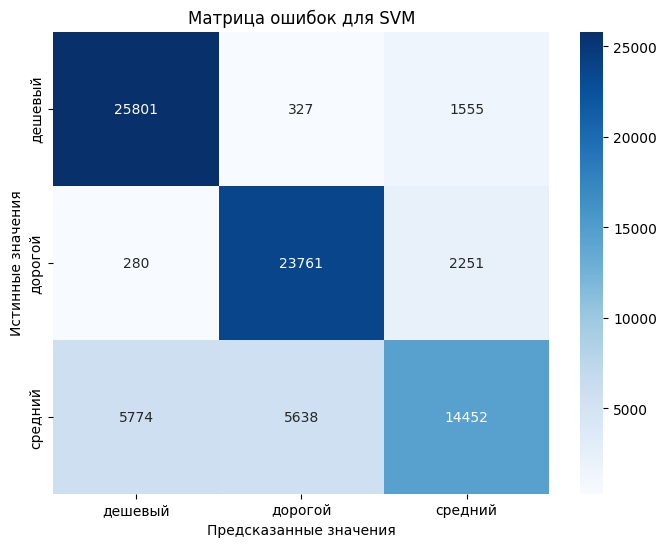

In [24]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_predict_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Матрица ошибок для SVM')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [37]:
model_knn = KNeighborsClassifier(n_neighbors=3)

model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
y_predict_knn = model_knn.predict(X_test)

#### Матрциа ошибок для KNN

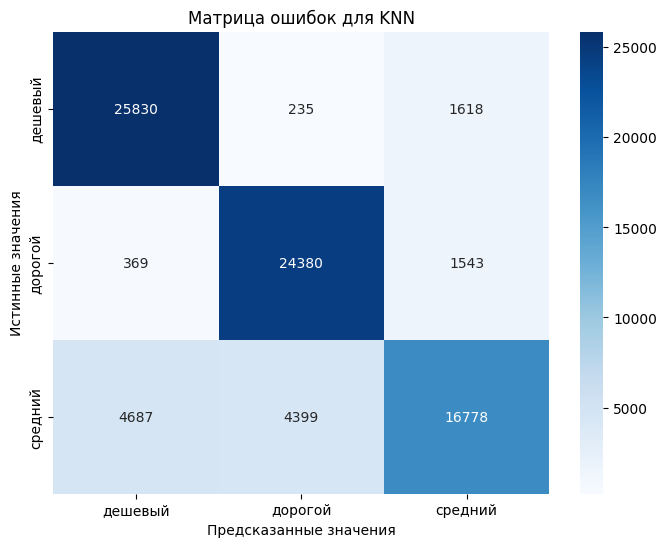

In [36]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_predict_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Матрица ошибок для KNN')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

## Задание №5

Сравнить результаты классификации, используя accuracy, precision,
recall и f1-меру (можно использовать classification_report из
sklearn.metrics). Сделать выводы.

In [42]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

     дешевый       0.89      0.89      0.89     27683
     дорогой       0.88      0.85      0.87     26292
     средний       0.75      0.78      0.76     25864

    accuracy                           0.84     79839
   macro avg       0.84      0.84      0.84     79839
weighted avg       0.84      0.84      0.84     79839



In [43]:
print(classification_report(y_test, y_predict_svm))

              precision    recall  f1-score   support

     дешевый       0.81      0.93      0.87     27683
     дорогой       0.80      0.90      0.85     26292
     средний       0.79      0.56      0.66     25864

    accuracy                           0.80     79839
   macro avg       0.80      0.80      0.79     79839
weighted avg       0.80      0.80      0.79     79839



In [44]:
print(classification_report(y_test, y_predict_knn))

              precision    recall  f1-score   support

     дешевый       0.88      0.88      0.88     27683
     дорогой       0.89      0.88      0.88     26292
     средний       0.77      0.77      0.77     25864

    accuracy                           0.85     79839
   macro avg       0.84      0.84      0.84     79839
weighted avg       0.85      0.85      0.85     79839

